In [79]:
import geopandas as gpd
import sys
from pathlib import Path
path = Path().cwd() / "src" #to add the src directory to the path regognized by Python
sys.path.append(str(path))
import methods_two_point_correlation as mtpc
import save_load_pickle as slp
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.spatial import distance
import matplotlib.pyplot as plt
import sklearn.cluster as sk
import sys
from sklearn.metrics import silhouette_score
from shapely.geometry import Polygon,Point
from scipy.stats import entropy

# Parameters

In [80]:
#set paths
path = Path().cwd()
sys.path.append(str(path))
data_dir = Path("data/cities")
map_dir = Path("data/map")

In [81]:
name = "Netherlands" #name of country
out_dir = Path.cwd() /Path(f"out/2pcf/{name}")
file = out_dir / "1_5_7000_3__100000.0_log_30" #name of dataset

diminish_radius = 0.5 # multiplication factor for the maximum radius, 
#to be change if the SP does not fit inside the considered border quick enough
nbins=30 # number of bins to make for every binning operation
N_run= 3 # number of random catalog generated for computing the 2PCF, needs to be the same as in the plotted data
size= 3000 #number of points each random catalog has
n_iteration=10 #number of model generated for the Kullback-Leibler divergence analysis
erase_nodes = False

In [82]:
#Load the polygon file for border
path_border = Path.cwd() / map_dir / f"{name}.geojson"
gdf_edge = gpd.read_file(path_border)

#load the results store in file
dico_results = slp.load_results(file)
r_edges = dico_results["r_edges"] #binning of distance for 2pcf
gamma, r0 = dico_results["fit_SP"] #fitted gamma and R0
l_xi = dico_results["xi"] # 2pcf
country_distribution = dico_results["distance_distribution"] #distance distribution
l_cluster = dico_results["clustering"] #5 best cluster value obtained with the silhouette score
N = dico_results["number_points"] #number of point sin the dataset
crs = mtpc.crs_selector(name) #cooridnate reference system associated with the datset
gdf_edge = gdf_edge.to_crs(crs) # Polygon of the border of the country

eta = l_cluster[0] #density, number of circles by steps
l = eta**(1/(2-gamma)) #fraction of space covered by the circles
L = int(np.log(N)/np.log(eta)+1)-1 #size of circles, number of steps
R = 0.5*gdf_edge.length[0]/(2*np.pi)*diminish_radius # radius max
min_rad = R/(l**(L-1))

rmin= np.min(r_edges)
rmax= np.max(r_edges)
k = N_run
scale="log"

In [83]:
print("gamma", gamma)
print("fractal dimension",np.log(eta)/np.log(l))
print("l = ", l)
print("L = ", L)

gamma 0.6542056589089592
fractal dimension 1.3457943410910407
l =  1.6737169688580982
L =  11


# Select the best combination of parameters
## Select the best combination of eta, L and number of random points to fit the synthetic 2pcf to the empirical one

In [84]:
def check_inside(lamb,eta,L,R,gdf_edge,erase_nodes=False):
    """ Produce a distribution of points of Soneira-Peebles that fit the border defined by gdf_edge
    Input:
        parameter to build the Soneira-Peebles:
        gdf_edge: geopandas of the border of the system of points
        erase_nodes: if int, erase the related number of nodes from the produced Soneira-Peebles
        
    Output:
        position: array of coordinates of the points generated
    """
    position,point_outside = soneira_peebles_border(lamb,eta,L,R,gdf_edge,erase_nodes)
    while len(point_outside) >= 1: #as long as not all the points fit hte border redo
        #print("Entering the loop")
        position,point_outside=soneira_peebles_border(lamb,eta,L,R,gdf_edge,erase_nodes)
    return position


def soneira_peebles_border(lamb,eta,L,R,gdf_edge,erase_nodes=False):
    """ Produce a distribution of points of Soneira-Peebles
    Input:
        parameter to build the Soneira-Peebles:
        gdf_edge: geopandas of the border of the system of points
        erase_nodes: if int, erase the related number of nodes from the produced Soneira-Peebles
        
    Output:
        position: array of coordinates of the points generated
        points_outside: count the number of points that lie outside of the border as defined by gdf_edge
    """
    position = gdf_edge.centroid.get_coordinates().to_numpy()
    final_position = []
    rng = np.random.default_rng()
    for i in range(L):
        l_pos = []
        for x,y in position:
            r = (R/(lamb**i))*np.random.uniform(low=0, high=1, size=eta)  # radius
            theta = np.random.uniform(low=0, high=2*np.pi, size=eta)  # angle
            l_x_rand = [r[i] * np.cos(theta[i]) for i in range(eta)]
            l_y_rand = [r[i] * np.sin(theta[i]) for i in range(eta)]
            l_point = [Point((x_rand,y_rand)) for x_rand,y_rand in zip(l_x_rand,l_y_rand)] 
            #l_random = (R/(lamb**i))*rng.random((eta,2))
            for x_rand,y_rand in zip(l_x_rand,l_y_rand):
                #s = geopandas.GeoSeries(point)
                l_pos.append((x-x_rand,y-y_rand))
        position = np.copy(l_pos)
        final_position = final_position + l_pos
    if type(erase_nodes) == int and erase_nodes >=0:
        print("enter erase")
        position = list(position)
        while erase_nodes != 0:
            index = rng.choice(range(len(position)))
            position.pop(index)
            erase_nodes -= 1
    position = np.array(position)
    #l_point = [Point(position[i]) for i in range(len(position))]
    s = gpd.GeoDataFrame(
          position, geometry=gpd.points_from_xy(position.T[0], position.T[1]),crs=crs)
    points_with_join = gpd.sjoin(s, gdf_edge, how="left", predicate="within")
    points_with_join['is_inside'] = points_with_join['index_right'].notna()
    point_outside = points_with_join[points_with_join["is_inside"] == False]
    return position,point_outside

def plot_two_2pcf(r_edges,l_xi,l_xi_SP):
    fig, ax = plt.subplots()
    sns.set(style="whitegrid")
    xi = np.mean(l_xi,axis=0)
    error = np.std(l_xi,axis=0)
    xi_SP = np.mean(l_xi_SP,axis=0)
    error = np.std(l_xi,axis=0)
    if len(xi) != len(r_edges): #when we choose a rmax define by user the code put an extra category above
        xi = xi[0:-1]
        error = error[0:-1]
        xi_SP = xi_SP[0:-1]
    color = sns.color_palette("viridis")[0]
    color_SP = sns.color_palette("viridis")[1]
    r_edges = r_edges[1:]
    xi = xi[1:]
    xi_SP = xi_SP[1:]
    error = error[1:]
    end = np.zeros([1])
    end[0] = 1.1*r_edges[-1]
    r_edges_zero = np.concatenate((r_edges,end))
    width = np.diff(r_edges_zero) #need to find a way to encode properly the first alignement
    ax.bar(r_edges,xi,width=width,align="center",edgecolor="black",color=color,alpha=0.5,label=f"{name}")
    ax.bar(r_edges,xi_SP,width=width,align="center",edgecolor="black",color=color_SP,alpha=0.5,label="SP")
    plt.errorbar(r_edges, xi, yerr=error, fmt="o", color="r",ms=1)
    title = "2 points correlation function "+name
    plt.title(title)
    plt.ylabel(r"$\xi(r)$")
    plt.xlabel(r"$r$ (meters)")
    plt.xscale("log")
    #plt.yscale("log")
    plt.legend()
    #plt.savefig(plot_dir / title, format="png",transparent=True)
    plt.show()

In [100]:
 """ Find the good paraemter L (number of steps) and the number of random nodes 
 needed to fit the 2pcf of the model (l_xi_random_SP) to the empirical 2pcf (l_xi)
Input:
    l_xi_random_SP: 2pcf of the original Soneira-Peebles without random point
    l_xi: 2pcf of the empirical system
    N: Number of points in the empirical system
    eta: number of points per step
Output:
    L: number of steps required  for the 2pcf of the SOneira-Peebles to fit the empircial one
    Nr: number of random points to add to the eta**L points of the Soneira-Peebles """
def find_good_L(l_xi_random_SP,l_xi,N,eta):
    ratio = np.abs([l_xi_random_SP[i]/l_xi[i] for i in range(len(l_xi))])
    alpha= 1/np.mean(ratio) 
    ratio = (1/np.sqrt(alpha)-1) #ratio of number of random points needed over the number of points from the SP model
    N_model = 1e-10
    #l_ratio = []
    #current_ratio= (N-N_model)/(N_model)
    #l_ratio.append(np.abs(ratio-current_ratio))
    i =0
    Nr=1e-10
    while N_model+Nr < N:
        i+=1
        N_model = eta**i
        Nr = int(ratio*N_model)
        #current_ratio= (N-N_model)/(N_model)
        #l_ratio.append(np.abs(ratio-current_ratio))
    L = i
    print(N_model,Nr,L)
    return L,Nr

def find_good_L(l,eta,L,R,gdf_edge,l_xi,N,iteration_pure_SP):
    l_alpha = []
    for i in range(iteration_pure_SP): # number of time we retry the 
        position = check_inside(l,eta,L,R,gdf_edge) #1st position for reference ie. the SP without random points
        position[-1] = [0,0] # trick to allow that the binning is done correctly for all datasets
        random_point = 0
        r_edges_random_SP,l_xi_random_SP = make_2pcf_for_model(position,crs,random_point,gdf_edge,rmax=rmax)
        ratio = np.abs([l_xi_random_SP[i]/l_xi[i] for i in range(len(l_xi))])
        l_alpha.append(1/np.mean(ratio))
    print(np.mean(l_alpha))
    print(l_alpha)
    alpha = np.mean(l_alpha)
    ratio = (1/np.sqrt(alpha)-1) #ratio of number of random points needed over the number of points from the SP model
    N_model = 1e-10
    #l_ratio = []
    #current_ratio= (N-N_model)/(N_model)
    #l_ratio.append(np.abs(ratio-current_ratio))
    i =0
    Nr=1e-10
    while N_model+Nr < N:
        i+=1
        N_model = eta**i
        Nr = int(ratio*N_model)
        #current_ratio= (N-N_model)/(N_model)
        #l_ratio.append(np.abs(ratio-current_ratio))
    L = i
    print(N_model,Nr,L)
    return L,Nr
    
 """ Make the 2pcf of the model (l_xi_random_SP) Soneira-Peebles + random
Input:
    position: Array of coordinates of points
    random_point: number of random points to add to the eta**L points of the Soneira-Peebles
    rmax: Number of points in the empirical system
Output:
    L: number of steps required  for the 2pcf of the SOneira-Peebles to fit the empircial one
    Nr: number of random points to add to the eta**L points of the Soneira-Peebles"""
def make_2pcf_for_model(position,crs,random_point,gdf_edge,rmax):
    d = {}
    d["x"] = position.T[0]
    d["y"] = position.T[1]
    gdf = gpd.GeoDataFrame(d, geometry=gpd.points_from_xy(position.T[0], position.T[1]),crs=crs)
    if random_point != 0:
        gdf_random_square = gdf_edge.sample_points(random_point)
        gdf_random_points = gpd.GeoDataFrame(gdf_random_square.explode().get_coordinates(),geometry=gdf_random_square.explode(),crs=crs)
        gdf = gpd.GeoDataFrame(pd.concat( [gdf,gdf_random_points], ignore_index=True))
    #print(len(gdf))
    r_edges_random_SP,l_xi_random_SP = mtpc.PCF_with_variance(gdf,gdf_edge,crs,N_run,size,k,rmax,scale,nbins=nbins,rmin=rmin)
    # Compute the 2 pcf with variance
    return r_edges_random_SP,l_xi_random_SP

In [103]:
 """ Find the parameters that best fit the 2pcf of the empirical system
Input:
    l_cluster: Array of coordinates of points
    number_of_try_for_each_parameter: several try for agiven paraemter set for the try of teh cost fucntion
    rmax: ramx in the system
Output:
    save_dist: for each eta and best try, store the cost function (euclidean distance)
    save_L: save the L that were tried, save_L[np.argmin(save_dist)] give teh best L of all
    save_random: save the number of random points that were tried, save_random[np.argmin(save_dist)] give teh best number of random points of all
    """
    

def find_the_fit_parameters_SP_random(l_cluster,N,R,gdf_edge,crs,rmax,number_of_try_for_each_parameter):
    save_dist = []
    save_L = [] #save best value of L for given eta (index)
    save_random = [] #save best valeur of random point for given eta (index)
    erase_nodes = 0
    for eta in l_cluster:
        #eta = l_cluster[1] #density, number of circles by steps
        l = eta**(1/(2-gamma)) #fraction of space covered by the circles
        L = int(np.log(N)/np.log(eta)) #size of circles, number of steps
        position = check_inside(l,eta,L,R,gdf_edge) #1st position for reference ie. the SP without random points
        position[-1] = [0,0] # trick to allow that the binning is done correctly for all datasets
        random_point = 0
        r_edges_random_SP,l_xi_random_SP = make_2pcf_for_model(position,crs,random_point,gdf_edge,rmax=rmax)
        print(len(l_xi),len(l_xi_random_SP))
        L,random_point = find_good_L(l_xi_random_SP,l_xi,N,eta)
        save_L.append(L)
        save_random.append(random_point)
        dist_between_distribution = 1e99
        for j in range(number_of_try_for_each_parameter): #for the given paraemters launch several try, to plot the best fit and see the value of the cost function
            position = check_inside(l,eta,L,R,gdf_edge)
            r_edges_random_SP,l_xi_random_SP = make_2pcf_for_model(position,crs,random_point,gdf_edge,rmax=rmax)
            if np.linalg.norm(np.mean(l_xi_random_SP,axis=0)-np.mean(l_xi,axis=0)) < dist_between_distribution: # euclidean cost function
                dist_between_distribution = np.linalg.norm(np.mean(l_xi_random_SP,axis=0)-np.mean(l_xi,axis=0))
                l_xi_SP = l_xi_random_SP
        save_dist.append(dist_between_distribution)
        print(L,eta,dist_between_distribution)
        plot_two_2pcf(r_edges,l_xi,l_xi_SP)
    return save_dist,save_L,save_random

def find_the_fit_parameters_SP_random(l_cluster,N,R,gdf_edge,crs,rmax,number_of_try_for_each_parameter,iteration_pure_SP):
    save_dist = []
    save_L = [] #save best value of L for given eta (index)
    save_random = [] #save best valeur of random point for given eta (index)
    erase_nodes = 0
    for eta in l_cluster:
        #eta = l_cluster[1] #density, number of circles by steps
        l = eta**(1/(2-gamma)) #fraction of space covered by the circles
        L = int(np.log(N)/np.log(eta)) #size of circles, number of steps
        L,Nr=find_good_L(l,eta,L,R,gdf_edge,l_xi,N,iteration_pure_SP)
        save_L.append(L)
        save_random.append(Nr)
        dist_between_distribution = 1e99
        for j in range(number_of_try_for_each_parameter): #for the given paraemters launch several try, to plot the best fit and see the value of the cost function
            position = check_inside(l,eta,L,R,gdf_edge)
            r_edges_random_SP,l_xi_random_SP = make_2pcf_for_model(position,crs,Nr,gdf_edge,rmax=rmax)
            if np.linalg.norm(np.mean(l_xi_random_SP,axis=0)-np.mean(l_xi,axis=0)) < dist_between_distribution: # euclidean cost function
                dist_between_distribution = np.linalg.norm(np.mean(l_xi_random_SP,axis=0)-np.mean(l_xi,axis=0))
                l_xi_SP = l_xi_random_SP
        save_dist.append(dist_between_distribution)
        print(L,eta,dist_between_distribution)
        plot_two_2pcf(r_edges,l_xi,l_xi_SP)
    return save_dist,save_L,save_random
    

0
1
rmax  100000.0
rmin 2137.414330263022
max DD 556133
min DD 5
maxRR 338116
minRR 14
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 2137.414330263022
max DD 556133
min DD 5
maxRR 336884
minRR 12
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 2137.414330263022
max DD 556133
min DD 5
maxRR 338322
minRR 26
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 2137.414330263022
max DD 615737
min DD 3
maxRR 337216
minRR 23
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 2137.414330263022
max DD 615737
min DD 3
maxRR 337548
minRR 22
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  1.0

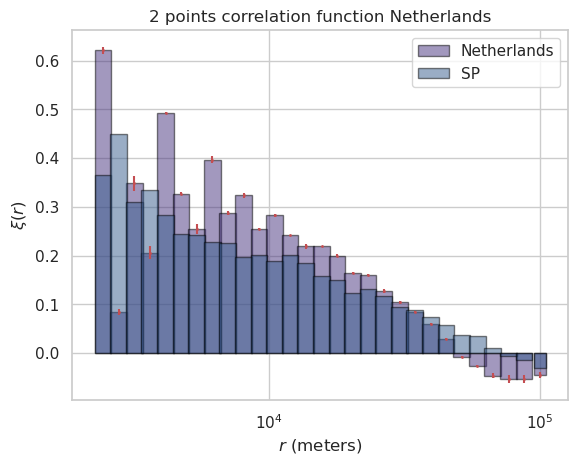

0
1
rmax  100000.0
rmin 2137.414330263022
max DD 541718
min DD 11
maxRR 337430
minRR 15
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 2137.414330263022
max DD 541718
min DD 11
maxRR 337985
minRR 26
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 2137.414330263022
max DD 541718
min DD 11
maxRR 339361
minRR 14
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 2137.414330263022
max DD 592536
min DD 5
maxRR 339827
minRR 15
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 2137.414330263022
max DD 592536
min DD 5
maxRR 337255
minRR 17
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  

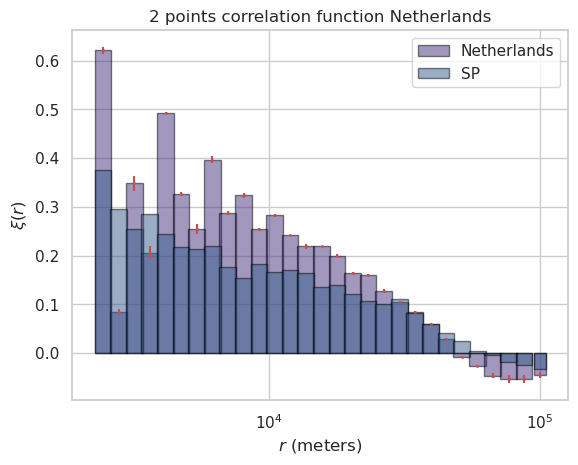

0
1
rmax  100000.0
rmin 2137.414330263022
max DD 534529
min DD 14
maxRR 337668
minRR 10
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 2137.414330263022
max DD 534529
min DD 14
maxRR 337717
minRR 33
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 2137.414330263022
max DD 534529
min DD 14
maxRR 336033
minRR 27
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 2137.414330263022
max DD 583296
min DD 6
maxRR 338745
minRR 10
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 2137.414330263022
max DD 583296
min DD 6
maxRR 339148
minRR 28
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  

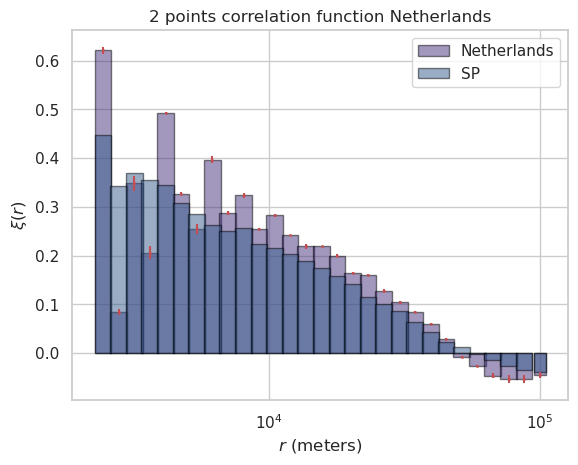

0
1
rmax  100000.0
rmin 2137.414330263022
max DD 536050
min DD 54
maxRR 338616
minRR 31
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 2137.414330263022
max DD 536050
min DD 54
maxRR 338067
minRR 36
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 2137.414330263022
max DD 536050
min DD 54
maxRR 338732
minRR 24
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 2137.414330263022
max DD 533708
min DD 35
maxRR 337595
minRR 22
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 2137.414330263022
max DD 533708
min DD 35
maxRR 338314
minRR 25
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD

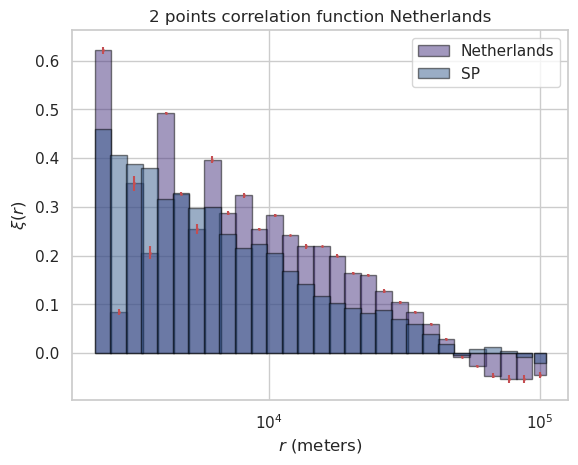

0
1
rmax  100000.0
rmin 2137.414330263022
max DD 556195
min DD 19
maxRR 337730
minRR 28
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  0.9999999999999999
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 2137.414330263022
max DD 556195
min DD 19
maxRR 337495
minRR 58
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  0.9999999999999999
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 2137.414330263022
max DD 556195
min DD 19
maxRR 338111
minRR 4
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  0.9999999999999999
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 2137.414330263022
max DD 604935
min DD 15
maxRR 337919
minRR 4
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  0.9999999999999999
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 2137.414330263022
max DD 604935
min DD 15
maxRR 339205
minRR 40
rmin,rmax= 213

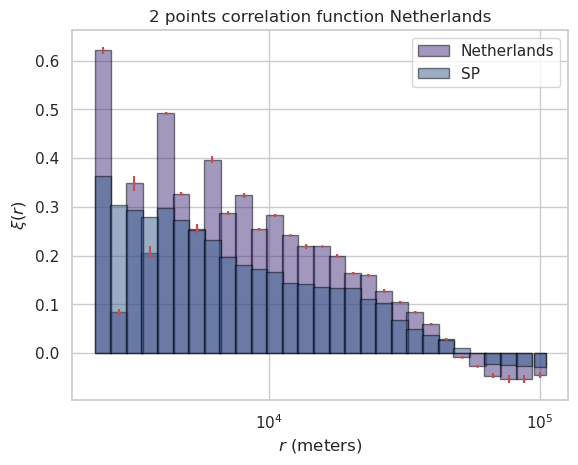

In [104]:
number_of_try_for_each_parameter = 5
iteration_pure_SP = 10
save_dist,save_L,save_random = find_the_fit_parameters_SP_random(l_cluster,N,R,gdf_edge,crs,rmax,number_of_try_for_each_parameter,iteration_pure_SP)

4096
0
1
rmax  100000.0
rmin 4033.510510773891
max DD 4313529
min DD 9
maxRR 1312972
minRR 35
rmin,rmax= 4033.510510773891 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 4033.510510773891
max DD 4313529
min DD 9
maxRR 1319981
minRR 160
rmin,rmax= 4033.510510773891 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 4033.510510773891
max DD 4313529
min DD 9
maxRR 1314871
minRR 93
rmin,rmax= 4033.510510773891 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
3 3
2048 7558 11
random point 7558
9606
0
1
rmax  100000.0
rmin 4033.510510773891
max DD 1303266
min DD 28
maxRR 1310417
minRR 105
rmin,rmax= 4033.510510773891 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 4033.510510773891
max DD 1303266
min DD 28
maxRR 1302653
minRR 30
rmin,rmax= 4033.51

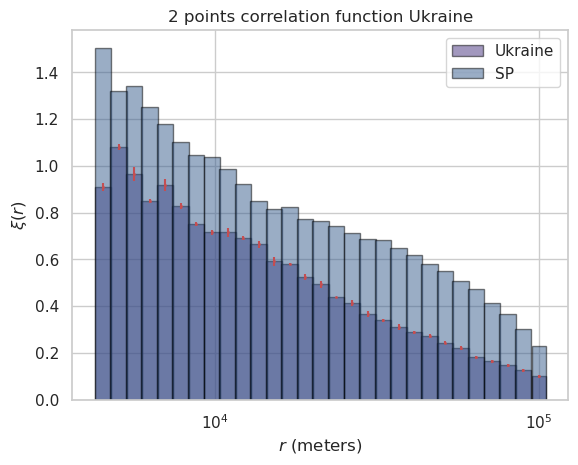

6561
0
1
rmax  100000.0
rmin 4033.510510773891
max DD 4362895
min DD 7
maxRR 1307082
minRR 163
rmin,rmax= 4033.510510773891 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 4033.510510773891
max DD 4362895
min DD 7
maxRR 1303650
minRR 27
rmin,rmax= 4033.510510773891 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 4033.510510773891
max DD 4362895
min DD 7
maxRR 1305670
minRR 54
rmin,rmax= 4033.510510773891 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
3 3
2187 8985 7
random point 8985
11172
0
1
rmax  100000.0
rmin 4033.510510773891
max DD 1310384
min DD 7
maxRR 1304238
minRR 70
rmin,rmax= 4033.510510773891 100000.0
lenRR 31
lenDD 31
normalization DD  0.9999999999999999
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 4033.510510773891
max DD 1310384
min DD 7
maxRR 1310847
minRR 20
rmin,r

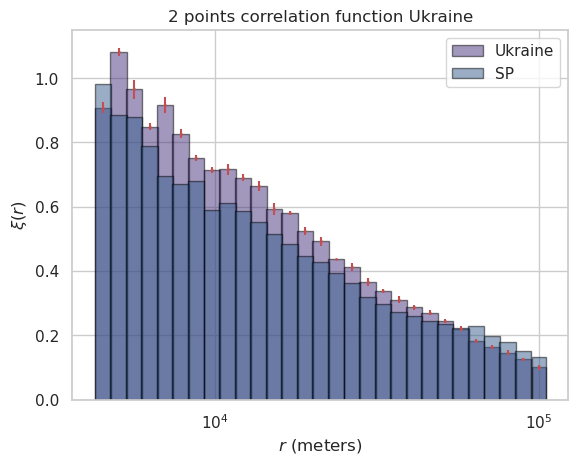

3125
0
1
rmax  100000.0
rmin 4033.510510773891
max DD 4261313
min DD 10
maxRR 1312657
minRR 39
rmin,rmax= 4033.510510773891 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 4033.510510773891
max DD 4261313
min DD 10
maxRR 1317448
minRR 81
rmin,rmax= 4033.510510773891 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 4033.510510773891
max DD 4261313
min DD 10
maxRR 1307602
minRR 58
rmin,rmax= 4033.510510773891 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
3 3
3125 11822 5
random point 11822
14947
0
1
rmax  100000.0
rmin 4033.510510773891
max DD 1316894
min DD 12
maxRR 1312247
minRR 117
rmin,rmax= 4033.510510773891 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 4033.510510773891
max DD 1316894
min DD 12
maxRR 1304763
minRR 97
rmin,rmax= 403

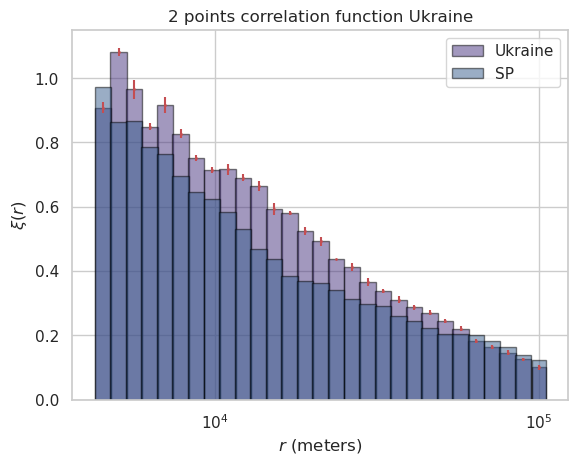

4096
0
1
rmax  100000.0
rmin 4033.510510773891
max DD 4260380
min DD 8
maxRR 1308816
minRR 85
rmin,rmax= 4033.510510773891 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 4033.510510773891
max DD 4260380
min DD 8
maxRR 1313825
minRR 41
rmin,rmax= 4033.510510773891 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 4033.510510773891
max DD 4260380
min DD 8
maxRR 1313175
minRR 57
rmin,rmax= 4033.510510773891 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
3 3
4096 14226 6
random point 14226
18322


KeyboardInterrupt: 

In [44]:
number_of_try_for_each_parameter = 1
save_dist = []
save_L = []
save_random = []
erase_nodes = 0
for eta in l_cluster:
    #eta = l_cluster[1] #density, number of circles by steps
    l = eta**(1/(2-gamma)) #fraction of space covered by the circles
    L = int(np.log(N)/np.log(eta)) #size of circles, number of steps
    position = check_inside(l,eta,L,R,gdf_edge)
    position[-1] = [0,0]
    random_point = 0
    r_edges_random_SP,l_xi_random_SP = make_2pcf_for_model(position,crs,random_point,gdf_edge,rmax=rmax)
    print(len(l_xi),len(l_xi_random_SP))
    L,random_point = find_good_L(l_xi_random_SP,l_xi,N,eta)
    save_L.append(L)
    save_random.append(random_point)
    dist_between_distribution = 1e99
    print("random point", random_point)
    for j in range(number_of_try_for_each_parameter):
        position = check_inside(l,eta,L,R,gdf_edge)
        r_edges_random_SP,l_xi_random_SP = make_2pcf_for_model(position,crs,random_point,gdf_edge,rmax=rmax)
        if np.linalg.norm(np.mean(l_xi_random_SP,axis=0)-np.mean(l_xi,axis=0)) < dist_between_distribution:
            dist_between_distribution = np.linalg.norm(np.mean(l_xi_random_SP,axis=0)-np.mean(l_xi,axis=0))
            l_xi_SP = l_xi_random_SP
    save_dist.append(dist_between_distribution)
    print(L,eta,dist_between_distribution)
    plot_two_2pcf(r_edges,l_xi,l_xi_SP)
print(l_cluster[np.argmin(save_dist)])

In [136]:
def compare_log_distribution(n_iteration,l,eta,L,R,gdf_edge,crs,number_point,random_point,erase_nodes,k,rmax,scale,nbins,country_distribution,show_histplot=False):
    KL_distanceSP = 1000
    KL_distance_random =1000
    positionSP,position_random = 0,0
    r_bins = np.logspace(np.log10(100),np.log10(np.max(country_distribution)+1),nbins)
    country_distribution_log = mtpc.binning_data(country_distribution,nbins,r_bins)
    save_random = 0
    save_SP = 0
    l_inter_SP = []
    l_inter_random = []
    for i in range(n_iteration):
        position = check_inside(l,eta,L,R,gdf_edge,erase_nodes)
        d = {}
        d["x"] = position.T[0]
        d["y"] = position.T[1]
        #df = pd.DataFrame((position))
        gdf = gpd.GeoDataFrame(
              d, geometry=gpd.points_from_xy(position.T[0], position.T[1]),crs=crs)
        gdf_random_square = gdf_edge.sample_points(random_point)
        gdf_random_points = gpd.GeoDataFrame(gdf_random_square.explode().get_coordinates(),geometry=gdf_random_square.explode(),crs=crs)
        gdf = gpd.GeoDataFrame(pd.concat( [gdf,gdf_random_points], ignore_index=True))
        print(len(gdf))
        l_index = [i for i in range(len(gdf))]
        to_drop = np.random.choice(l_index,size=len(l_index)-N,replace=False)
        gdf.drop(to_drop, inplace=True)
        print(len(gdf))
        position = gdf.get_coordinates().values
        r_edge,l_xi_SP = make_2pcf_for_model(position,crs,0,gdf_edge,rmax)
        plot_two_2pcf(r_edges,l_xi,l_xi_SP)
        #ax = gdf_edge.plot()
        #gdf.plot(ax=ax,color="red",markersize=0.5)
        #plt.show()
        gdf_projected_random= mtpc.generate_random_point(gdf_edge,number_point,crs,check_gpd=True)
        #r_edges_random_SP,l_xi_random_SP = mtpc.PCF_with_variance(gdf_projected_random,gdf_edge,crs,N_run,size,k,rmax,scale,nbins=nbins)
        distance_distribution_random_nobin = mtpc.compute_DD(gdf_projected_random)
        distance_distribution_SP_nobin = mtpc.compute_DD(gdf)
        distance_distribution_SP = mtpc.binning_data(distance_distribution_SP_nobin,nbins,r_bins)[0:nbins]
        distance_distribution_random = mtpc.binning_data(distance_distribution_random_nobin,nbins,r_bins)[0:nbins]

        distance_distribution_random = distance_distribution_random/np.sum(distance_distribution_random)
        distance_distribution_SP = distance_distribution_SP/np.sum(distance_distribution_SP)
        KL_distanceSP_inter = entropy(country_distribution_log+1,distance_distribution_SP+1)
        KL_distance_random_inter = entropy(country_distribution_log+1,distance_distribution_random+1)
        l_inter_SP.append(KL_distanceSP_inter) 
        l_inter_random.append(KL_distance_random_inter)
        if show_histplot:
            stat="density"
            sns.histplot(country_distribution,bins=nbins,stat="density",label="original",legend=True,log_scale=True)
            sns.histplot(distance_distribution_SP_nobin,bins=nbins,stat="density",label="SP",legend=True,log_scale=True)
            sns.histplot(distance_distribution_random_nobin,bins=nbins,stat="density",label="random",legend=True,log_scale=True)
            plt.yscale("log")
            plt.legend()
            plt.show()
    return l_inter_SP,l_inter_random

In [132]:
save_dist

[0.8326597110805226,
 0.8048366112571337,
 0.7616677648644794,
 0.8535655809896748,
 0.7941872538182952]

In [133]:
l_cluster

array([2, 3, 4, 5, 6])

In [134]:
save_L

[9, 6, 5, 4, 4]

In [135]:
save_random

[3694, 5081, 6705, 3947, 8500]

7729
2535
0
1
rmax  100000.0
rmin 2137.414330263022
max DD 333680
min DD 2
maxRR 336884
minRR 11
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 2137.414330263022
max DD 333680
min DD 2
maxRR 338889
minRR 37
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 2137.414330263022
max DD 333680
min DD 2
maxRR 338716
minRR 25
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


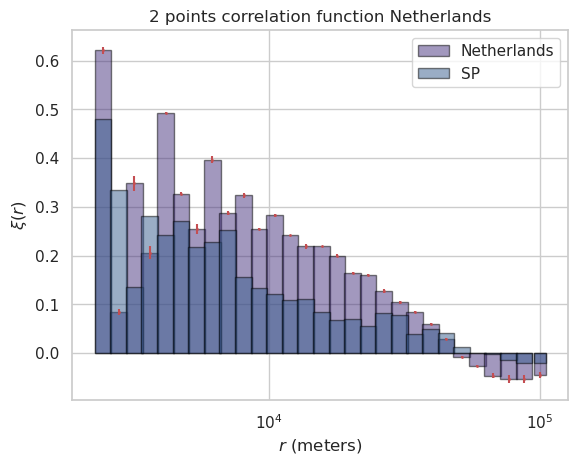

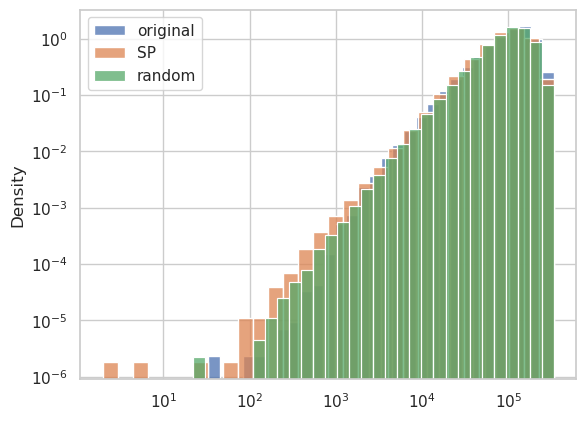

7729
2535
0
1
rmax  100000.0
rmin 2137.414330263022
max DD 332254
min DD 45
maxRR 338772
minRR 27
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 2137.414330263022
max DD 332254
min DD 45
maxRR 336966
minRR 39
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 2137.414330263022
max DD 332254
min DD 45
maxRR 338480
minRR 38
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


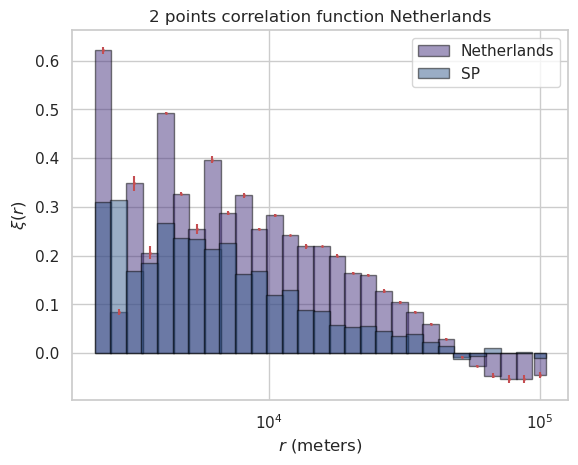

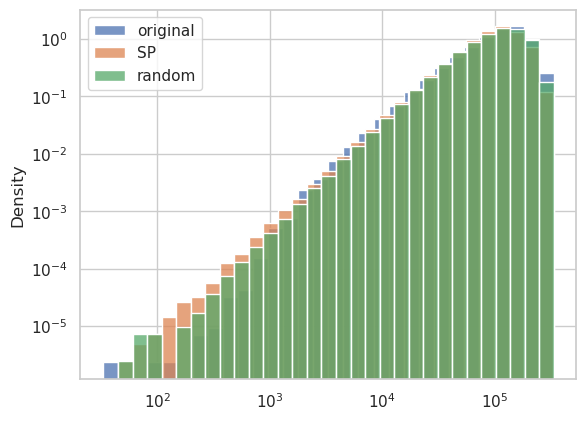

7729
2535
0
1
rmax  100000.0
rmin 2137.414330263022
max DD 337002
min DD 31
maxRR 337109
minRR 5
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 2137.414330263022
max DD 337002
min DD 31
maxRR 338794
minRR 56
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 2137.414330263022
max DD 337002
min DD 31
maxRR 336921
minRR 29
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


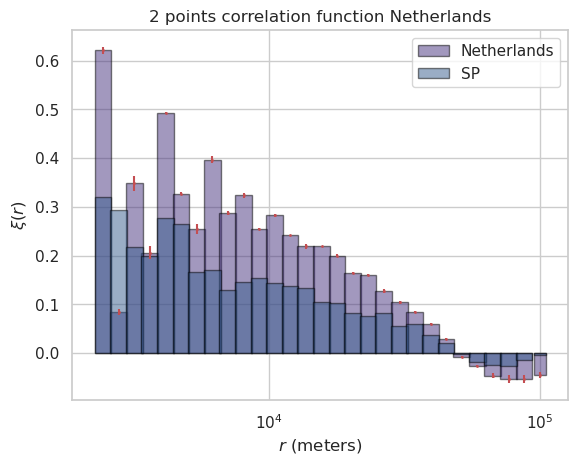

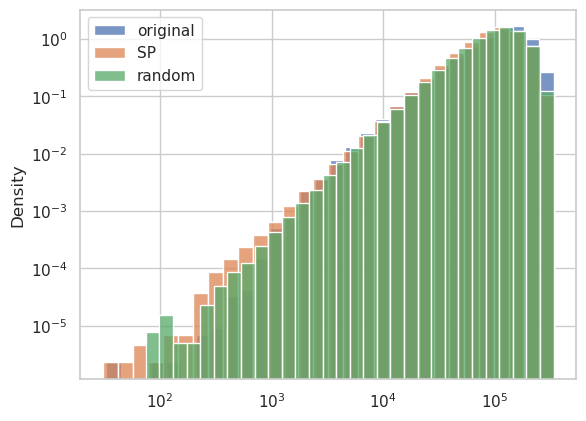

7729
2535
0
1
rmax  100000.0
rmin 2137.414330263022
max DD 336646
min DD 7
maxRR 336485
minRR 29
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 2137.414330263022
max DD 336646
min DD 7
maxRR 338557
minRR 32
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 2137.414330263022
max DD 336646
min DD 7
maxRR 338059
minRR 26
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


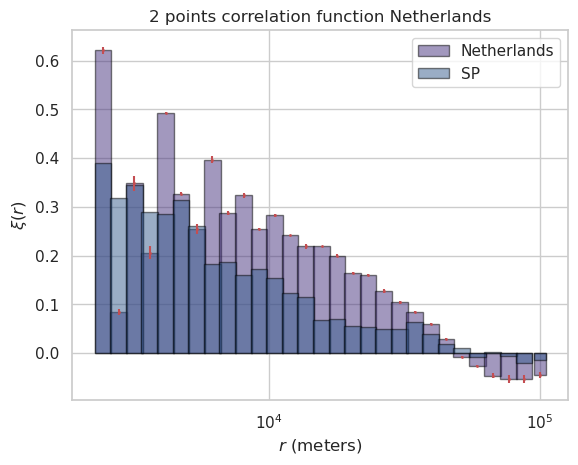

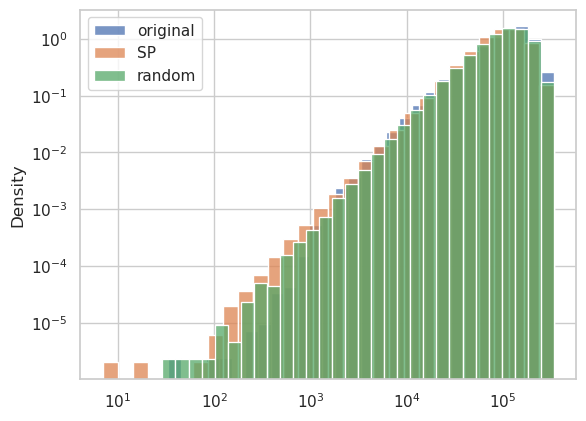

7729
2535
0
1
rmax  100000.0
rmin 2137.414330263022
max DD 339358
min DD 59
maxRR 336844
minRR 24
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 2137.414330263022
max DD 339358
min DD 59
maxRR 338519
minRR 26
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 2137.414330263022
max DD 339358
min DD 59
maxRR 337375
minRR 27
rmin,rmax= 2137.414330263022 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


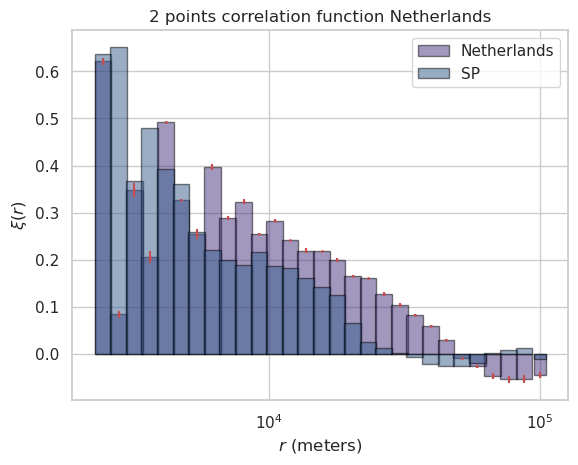

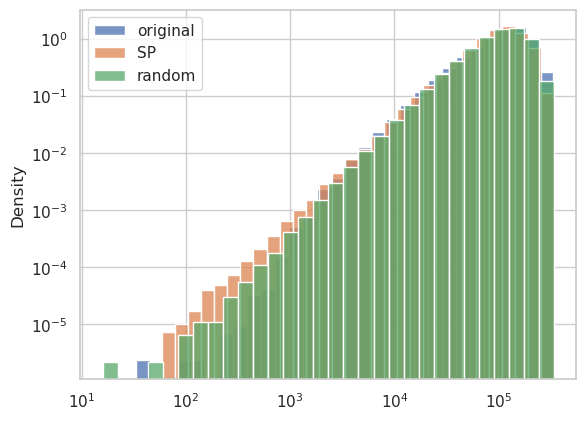

In [137]:
n_iteration = 5
L = save_L[np.argmin(save_dist)] #np.argmin(save_dist)
eta = l_cluster[np.argmin(save_dist)]
l = eta**(1/(2-gamma))
random_point = save_random[np.argmin(save_dist)]
# KLSP,KLrandom
show_histplot= True
KLSP,KLrandom = compare_log_distribution(n_iteration,l,eta,L,R,gdf_edge,crs,N,random_point,erase_nodes,k,rmax,scale,nbins,country_distribution,show_histplot)

In [138]:
np.min(KLrandom)

1.0866768755743397

In [139]:
np.min(KLSP)

1.0876921928047463

TtestResult(statistic=-3.9784172391964967, pvalue=0.0020353491085401726, df=8.0)


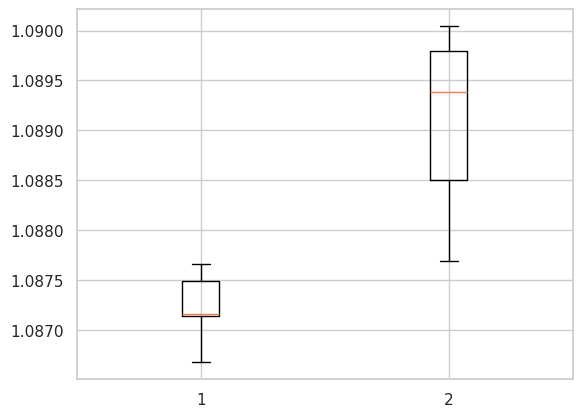

In [140]:
plt.boxplot([KLrandom,KLSP])
from scipy.stats import ttest_ind
print(ttest_ind(KLrandom,KLSP,alternative="less"))

1024
2535


<Axes: >

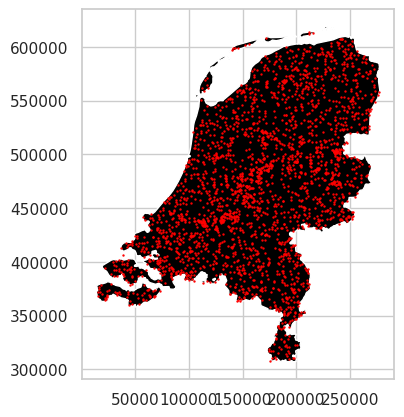

In [141]:
position = check_inside(l,eta,L,R,gdf_edge)
d = {}
d["x"] = position.T[0]
d["y"] = position.T[1]
gdf = gpd.GeoDataFrame(d, geometry=gpd.points_from_xy(position.T[0], position.T[1]),crs=crs)
print(len(gdf))
gdf_random_square = gdf_edge.sample_points(random_point)
gdf_random_points = gpd.GeoDataFrame(gdf_random_square.explode().get_coordinates(),geometry=gdf_random_square.explode(),crs=crs)
gdf = gpd.GeoDataFrame(pd.concat( [gdf,gdf_random_points], ignore_index=True))
l_index = [i for i in range(len(gdf))]
to_drop = np.random.choice(l_index,size=len(l_index)-N,replace=False)
gdf.drop(to_drop, inplace=True)
print(len(gdf))
convex_hull_polygon = gdf.union_all()
polygon = convex_hull_polygon.convex_hull
geoserie = gpd.GeoSeries(polygon)
squares_gdf=gpd.GeoDataFrame({'geometry': geoserie, 'df':[1]},crs=crs)
fig,ax = plt.subplots()
#squares_gdf.plot(ax=ax)
gdf_edge.plot(ax=ax,color="black")
gdf.plot(ax=ax,color="red",markersize=0.5)